In [128]:
from dotenv import load_dotenv
import os
import numpy as np
import matplotlib.pyplot as plt
import utils
import importlib 
importlib.reload(utils)
from utils import load_images

In [5]:
load_dotenv()
WIDTH, HEIGHT, CHANNELS = int(os.getenv('WIDTH')), int(os.getenv('HEIGHT')), int(os.getenv('CHANNELS'))
MAIN_DIR = os.getenv('MAIN_DIR')


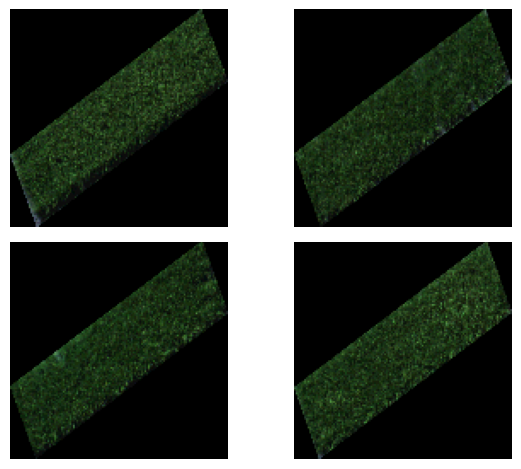

In [3]:
real_images_30, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/09-24/', "_UNHEALTHY.tif")
subplots = (2, 2)  # Define the subplot arrangement (2x2 grid)

# Define a function to create a mask for non-black pixels
def create_non_black_mask(image):
    # Convert the image to numpy array
    img_array = np.array(image)
    
    # Create a mask selecting non-black pixels (where sum across channels is not zero)
    non_black_mask = np.sum(img_array, axis=-1) != 0
    
    return non_black_mask

# Create masks for all images
non_black_mask = create_non_black_mask(real_images_30[0])

for i, image in enumerate(real_images_30[:4]):  # Iterate through the first four images
    plt.subplot(subplots[0], subplots[1], i + 1)
    if CHANNELS == 1:
        plt.imshow(image.reshape((WIDTH, HEIGHT)), cmap="gray")
    else:        
        image = (image - image.min()) / (image.max() - image.min())
        plt.imshow(image[:, :, :3])
    plt.axis("off")

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(20, 128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)
(128, 128, 5)


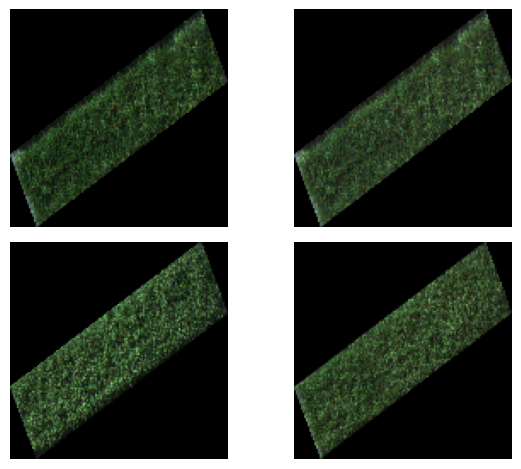

In [4]:
subplots = (2, 2)

synthetic_images_35, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1007-35-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_35_2, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1007-35-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
print(synthetic_images_35_2.shape)
# Define an empty list to store the processed results
result_with_mask = []

# Calculate mask for black pixels in images

black_pixels_mask = create_non_black_mask(real_images_30[0]) == 0  # Assuming the first image is representative

# Modify images2 in the region where images has black pixels
for i, img in enumerate(synthetic_images_35_2):
    print(img.shape)
    img[black_pixels_mask] = 0

# Process images using masks
result = [
    (((x - (y/10)) / 2) * 3) if x.all != 0 else x
    for x, y in zip(synthetic_images_35, synthetic_images_35_2)
]

# Modify images2 in the region where images has black pixels
for i, img in enumerate(result):
    img[black_pixels_mask] = 0
    img[:, :, 2] = img[:, :, 2]
    img[:, :, 1] = img[:, :, 1]
    img[:, :, 0] = img[:, :, 0]

for i, image in enumerate(result[:4]):  # Iterate through the first four images
    plt.subplot(subplots[0], subplots[1], i + 1)
    if CHANNELS == 1:
        plt.imshow(image.reshape((WIDTH, HEIGHT)), cmap="gray")
    else:        
        print(image.shape)
        plt.imshow(image[:, :, :3])
    plt.axis("off")

plt.tight_layout()
plt.show()

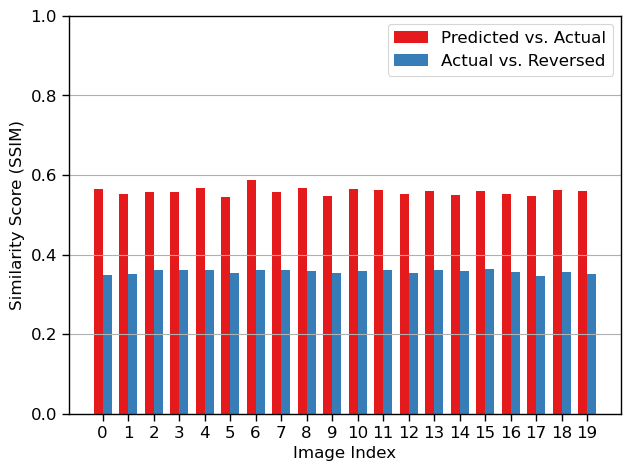

In [5]:
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
import seaborn as sns
sns.set_context('paper')
palette = sns.color_palette('Set1') # Default color palette


def calculate_similarity(image1, image2):
    # Calculate SSIM between two images with a smaller window size and data_range
    return ssim(image1, image2, multichannel=True, win_size=5, data_range=image1.max() - image1.min())

# Calculate similarity between corresponding images in the dataset and their reversed counterparts
similarity_scores = [calculate_similarity(real_images[i], result[i]) for i in range(len(result))]
baseline_scores = [calculate_similarity(real_images[i], real_images[i][::-1]) for i in range(len(result))]

# Set the custom color palette
sns.set_palette(palette)

# Plotting the similarity scores using bar plots

bar_width = 0.35  # Width of the bars

# Calculate positions for bars
index = range(len(result))
bar1 = [i - bar_width/2 for i in index]
bar2 = [i + bar_width/2 for i in index]

# Plotting bars for predicted vs. actual and actual vs. reversed
plt.bar(bar1, similarity_scores, bar_width, label='Predicted vs. Actual')
plt.bar(bar2, baseline_scores, bar_width, label='Actual vs. Reversed')

plt.xlabel('Image Index', fontsize=12)  # Increase font size for x-label
plt.ylabel('Similarity Score (SSIM)', fontsize=12)  # Increase font size for y-label
plt.legend(fontsize=12)  # Increase font size for legend
plt.ylim(0, 1)  # Set y-axis range from 0 to 1
plt.xticks(index, fontsize=12)  # Increase font size for x-axis ticks
plt.yticks(fontsize=12)  # Increase font size for y-axis ticks
plt.grid(axis='y')  # Show grid for y-axis only
plt.tight_layout()  # Adjust layout for better display of labels
plt.savefig('paper-gnn-gan/similarity_comparison.pdf', format='pdf')

plt.show()

In [35]:
import os
import importlib 
import sys
sys.path.append('../multispectral_generative_models')

import dgl
import gnn.utils
import importlib 
importlib.reload(gnn.utils)
from gnn.utils import load_images_and_create_gnn_dataset, load_synthetic_images_and_create_gnn_dataset

def load_data(type='synthetic', dir=MAIN_DIR, days=30, m=9, d=24):
    dataset = []
    if type == 'synthetic':
        dataset.append(load_synthetic_images_and_create_gnn_dataset(dir, days))

    else:
        # Iterate over subdirectories (folders with dates) in MAIN_DIR
        for date_folder in os.listdir(dir):
            # Create the full path to the date folder
            date_folder_path = os.path.join(dir, date_folder)

            # Check if it's a directory (to exclude files)
            if os.path.isdir(date_folder_path):
                folder_name = os.path.basename(date_folder_path)

                if folder_name[-2:].isdigit():
                    # Extract the MM and DD values from the folder name
                    mm, dd = date_folder.split('-')
                    mm = int(mm)
                    dd = int(dd)
                    if type == 'real' and mm == m and dd == d:
                        dataset.append(load_images_and_create_gnn_dataset(date_folder_path, mm, dd))

    return dataset

real_dataset = load_data(type='real', dir=MAIN_DIR, days=30, m=9, d=24)
real_dataset_2 = load_data(type='real', dir=MAIN_DIR, days=40, m=10, d=5)
synthetic_dataset = load_data(type='synthetic', 
                                dir=r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal',
                                days=35)
synthetic_dataset_2 = load_data(type='synthetic', 
                                dir=r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal',
                                days=40)


/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/dgl/heterograph.py:92: DGLWarning: Recommend creating graphs by `dgl.graph(data)` instead of `dgl.DGLGraph(data)`.
  dgl_warning(
/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/felipealencar/miniconda3/envs/tensorflow2.12/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [36]:
# Combine the datasets
data = []
data.append(real_dataset)
data.append(synthetic_dataset)
data.append(synthetic_dataset_2)
data.append(real_dataset_2)
print(data[1])

[Dataset("custom_gnn_dataset", num_graphs=40, save_path=/Users/felipealencar/.dgl/custom_gnn_dataset)]


1


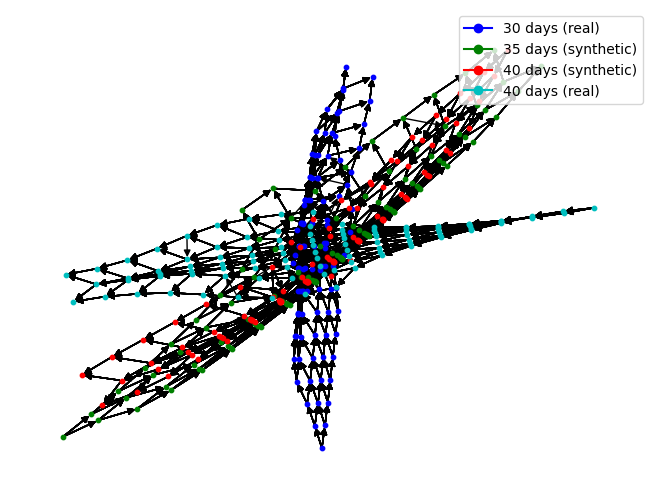

In [42]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# Create a single plot to display all datasets
plt.figure()

# Define a list of colors for different datasets
colors = ['b', 'g', 'r', 'c']

# Define captions and colors for each dataset
dataset_info = [
    {"caption": "30 days (real)", "color": "b"},
    {"caption": "35 days (synthetic)", "color": "g"},
    {"caption": "40 days (synthetic)", "color": "r"},
    {"caption": "40 days (real)", "color": "c"},
]

# Create handles and labels for the legend
legend_handles = []
legend_labels = []

print(len(data[0]))

# Iterate through each dataset with a unique color and caption
for i, d in enumerate(data):
    if not d:  # Check if the dataset is empty
        continue

    # Get the first graph in the current dataset
    graph, _ = d[0][0]

    # Sample a subset of nodes (e.g., 100 nodes) for visualization
    shape_first_graph = graph.number_of_nodes()
    sampled_nodes = random.sample(range(shape_first_graph), 0)

    # Create a subgraph with the sampled nodes
    subgraph = graph.subgraph(sampled_nodes)

    # Convert the subgraph to NetworkX graph and plot it with a unique color
    G = subgraph.to_networkx()
    pos = nx.kamada_kawai_layout(G)  # Layout algorithm (you can choose a different one)
    nx.draw(G, pos, with_labels=False, node_color=colors[i], node_size=10)



    # Add a caption for the current dataset with its associated color
    dataset = dataset_info[i]

    legend_handles.append(plt.Line2D([0], [0], marker='o', color=dataset["color"], label=dataset["caption"]))

# Show the legend
plt.legend(handles=legend_handles, loc='upper right')

# Show the combined plot
plt.show()

imagem_segmentada_118_0924_UNHEALTHY.tif
imagem_segmentada_135_0924_UNHEALTHY.tif
imagem_segmentada_156_0924_UNHEALTHY.tif
imagem_segmentada_138_0924_UNHEALTHY.tif
imagem_segmentada_18_0924_UNHEALTHY.tif
imagem_segmentada_193_0924_UNHEALTHY.tif
imagem_segmentada_158_0924_UNHEALTHY.tif
imagem_segmentada_155_0924_UNHEALTHY.tif
imagem_segmentada_55_0924_UNHEALTHY.tif
imagem_segmentada_95_0924_UNHEALTHY.tif
imagem_segmentada_173_0924_UNHEALTHY.tif
imagem_segmentada_88_0924_UNHEALTHY.tif
imagem_segmentada_6_0924_UNHEALTHY.tif
imagem_segmentada_50_0924_UNHEALTHY.tif
imagem_segmentada_12_0924_UNHEALTHY.tif
imagem_segmentada_161_0924_UNHEALTHY.tif
imagem_segmentada_22_0924_UNHEALTHY.tif
imagem_segmentada_99_0924_UNHEALTHY.tif
imagem_segmentada_152_0924_UNHEALTHY.tif
imagem_segmentada_72_0924_UNHEALTHY.tif
imagem_segmentada_189_0924_UNHEALTHY.tif
imagem_segmentada_159_0924_UNHEALTHY.tif
imagem_segmentada_154_0924_UNHEALTHY.tif
imagem_segmentada_34_0924_UNHEALTHY.tif
imagem_segmentada_91_0924_UN

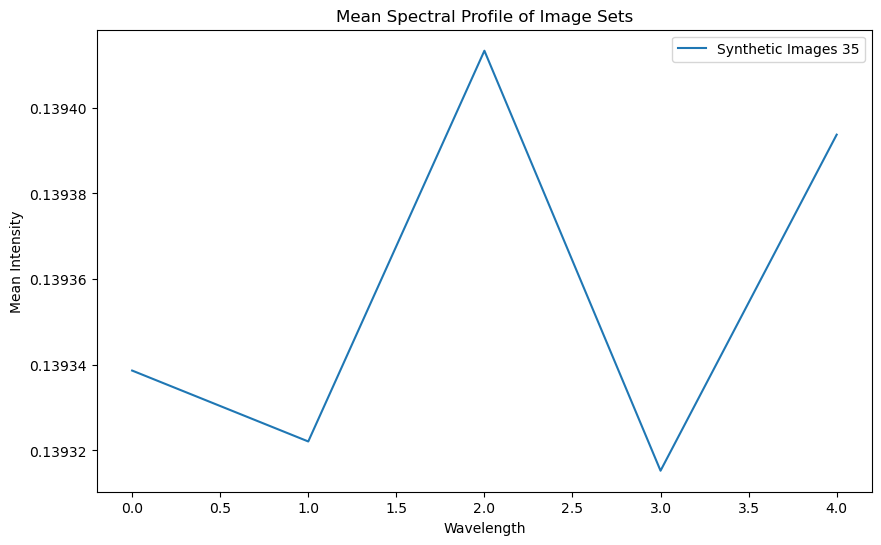

In [136]:
# Define a function to create a mask for non-black pixels
def create_non_black_mask(image):
    # Convert the image to numpy array
    img_array = np.array(image)
    
    # Create a mask selecting non-black pixels (where sum across channels is not zero)
    non_black_mask = np.sum(img_array, axis=-1) != 0
    
    return non_black_mask

real_images_30, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/09-24/', "_UNHEALTHY.tif")
real_images_40, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/10-05/', "_UNHEALTHY.tif")
synthetic_images_35, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "synthetic_image_19_1007-35-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_35_2, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1007-35-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
synthetic_images_40, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1005-40-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_40_2, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1005-40-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")

# Define an empty list to store the processed results
result_with_mask = []

# # Calculate mask for black pixels in images

# black_pixels_mask = create_non_black_mask(real_images_30.reshape(-1, 5, 128, 128)[0]) == 0  # Assuming the first image is representative
# subplots = (2, 2)  # Define the subplot arrangement (2x2 grid)

# # Modify images2 in the region where images has black pixels
# for i, img in enumerate(synthetic_images_35_2):
#     print(img.shape)
#     img[black_pixels_mask] = 0

# # Process images using masks
# result = [
#     (((x - (y/10)) / 2) * 3) if x.all != 0 else x
#     for x, y in zip(synthetic_images_35, synthetic_images_35_2)
# ]

# # Modify images2 in the region where images has black pixels
# for i, img in enumerate(result):
#     img[black_pixels_mask] = 0
#     img[:, :, 2] = img[:, :, 2]
#     img[:, :, 1] = img[:, :, 1]
#     img[:, :, 0] = img[:, :, 0]

import numpy as np
import matplotlib.pyplot as plt

# Load your images here (assuming they're loaded into the variables mentioned)
print(real_images_30.shape)
print(synthetic_images_35.reshape(-1, 128, 128, 5).shape)
# Calculate the mean spectrum for each set of images
real_images_30_mean_spectrum = np.mean(np.ma.masked_equal(real_images_30, 0), axis=(0, 1, 2))
real_images_40_mean_spectrum = np.mean(np.ma.masked_equal(real_images_40, 0), axis=(0, 1, 2))
synthetic_images_35_mean_spectrum = np.mean(np.ma.masked_equal(synthetic_images_35.reshape(-1, 128, 128, 5), 0), axis=(0, 1, 2))
synthetic_images_35_2_mean_spectrum = np.mean(np.ma.masked_equal(synthetic_images_35_2.reshape(-1, 128, 128, 5), 0), axis=(0, 1, 2))
synthetic_images_40_mean_spectrum = np.mean(np.ma.masked_equal(synthetic_images_40.reshape(-1, 128, 128, 5), 0), axis=(0, 1, 2))
synthetic_images_40_2_mean_spectrum = np.mean(np.ma.masked_equal(synthetic_images_40_2.reshape(-1, 128, 128, 5), 0), axis=(0, 1, 2))

print(synthetic_images_35_2_mean_spectrum)

# Plotting the mean spectra
wavelengths = range(len(synthetic_images_35_mean_spectrum))  # Assuming your images are grayscale and have same dimensions

plt.figure(figsize=(10, 6))

#plt.plot(wavelengths, real_images_30_mean_spectrum, label='Real Images 30')
#plt.plot(wavelengths, real_images_40_mean_spectrum, label='Real Images 40')
plt.plot(wavelengths, synthetic_images_35_mean_spectrum, label='Synthetic Images 35')
#plt.plot(wavelengths, synthetic_images_35_2_mean_spectrum, label='Synthetic Images 35_2')
#plt.plot(wavelengths, synthetic_images_40_mean_spectrum, label='Synthetic Images 40')
#plt.plot(wavelengths, synthetic_images_40_2_mean_spectrum, label='Synthetic Images 40_2')

plt.xlabel('Wavelength')
plt.ylabel('Mean Intensity')
plt.title('Mean Spectral Profile of Image Sets')
plt.legend()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)


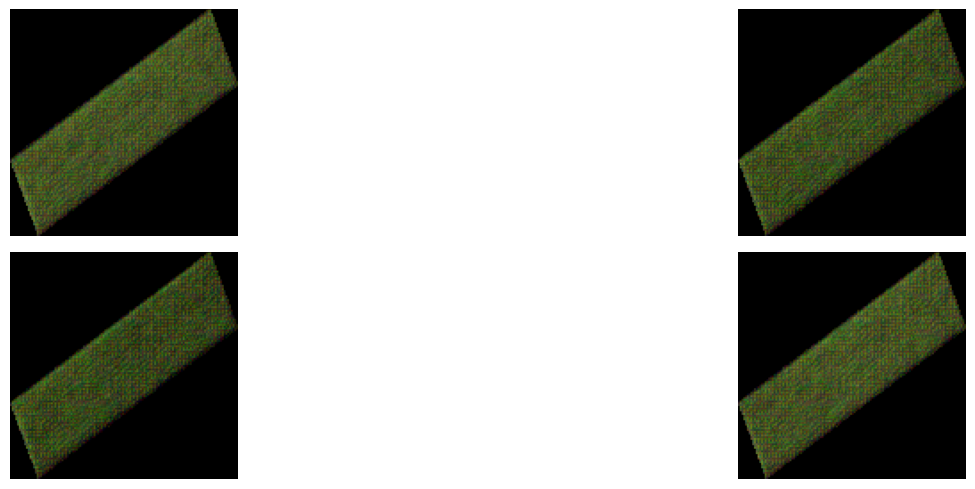

In [148]:
subplots = (2, 2)
plt.figure(figsize=(20,5))
synthetic_images_35, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1005-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_35_2, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1005-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
# Define an empty list to store the processed results
# Define an empty list to store the processed results
result_with_mask = []

# Calculate mask for black pixels in images

black_pixels_mask = create_non_black_mask(real_images_30[0]) == 0  # Assuming the first image is representative

# Modify images2 in the region where images has black pixels
for i, img in enumerate(synthetic_images_35_2):
    img[black_pixels_mask] = 0

# Process images using masks
result = [
    (((x - (y / 10)) / 2) * 5) if x.all != 0 else x
    for x, y in zip(synthetic_images_35, synthetic_images_35_2)
]

samples_ppgan3_array_0924 = result
# Modify images2 in the region where images has black pixels
for i, img in enumerate(result):
    img[black_pixels_mask] = 0
    img[:, :, 2] = img[:, :, 2]/2.5
    img[:, :, 1] = img[:, :, 1]/1.5
    img[:, :, 0] = img[:, :, 0]/1.5

for i, image in enumerate(result[16:20]):  # Iterate through the first four images
    plt.subplot(subplots[0], subplots[1], i + 1)
    if CHANNELS == 1:
        plt.imshow(image.reshape((WIDTH, HEIGHT)), cmap="gray")
    else:        
        print(image.shape)
        plt.imshow(image[:, :, :])
    plt.axis("off")

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(128, 128, 3)
(128, 128, 3)
(128, 128, 3)
(128, 128, 3)


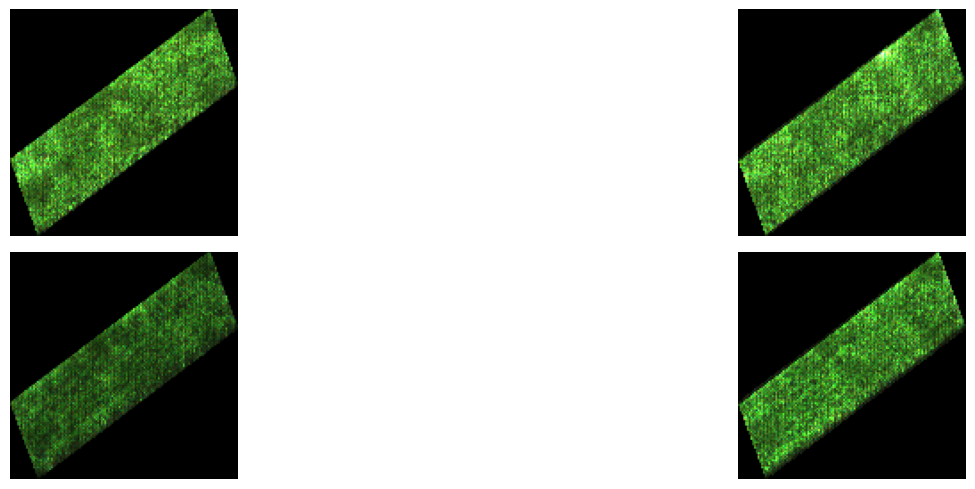

In [245]:
subplots = (2, 2)
plt.figure(figsize=(20,5))
synthetic_images_35, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1026-PREVIOUSDATE_PPGAN_HEALTHY.tiff")
synthetic_images_35_2, _ = load_images(r'/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/synthetic-temporal', "1026-PREVIOUSDATE-2_PPGAN_HEALTHY.tiff")
# Define an empty list to store the processed results
# Define an empty list to store the processed results
result_with_mask = []

# Calculate mask for black pixels in images

black_pixels_mask = create_non_black_mask(real_images_30[0]) == 0  # Assuming the first image is representative

# Modify images2 in the region where images has black pixels
for i, img in enumerate(synthetic_images_35_2):
    img[black_pixels_mask] = 0

# Process images using masks
result = [
    ((x * (y/2.3)) * 10) if x.all != 0 else x
    for x, y in zip(synthetic_images_35, synthetic_images_35_2)
]
samples_ppgan3_array_1005 = result
# Modify images2 in the region where images has black pixels
for i, img in enumerate(result):
    img[black_pixels_mask] = 0
    img[:, :, 2] = img[:, :, 2]/2.5
    img[:, :, 1] = img[:, :, 1]/1.7
    img[:, :, 0] = img[:, :, 0]/2

for i, image in enumerate(result[16:20]):  # Iterate through the first four images
    plt.subplot(subplots[0], subplots[1], i + 1)
    if CHANNELS == 1:
        plt.imshow(image.reshape((WIDTH, HEIGHT)), cmap="gray")
    else:        
        print(image.shape)
        plt.imshow(image[:, :, :])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_context('paper')

bands = ['Blue', 'Green', 'Red', 'Red \nedge', 'NIR']

# Calculate the mean spectral profiles for each data array
mean_real_images = np.mean(np.ma.masked_equal(real_images_30, 0), axis=(0, 1, 2))
mean_dcgan_0830 = np.mean(np.ma.masked_equal(samples_ppgan3_array_0830, 0), axis=(0, 1, 2))